In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as funcy
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

In [2]:
dev='cuda' if torch.cuda.is_available() else 'cpu'
dev

'cuda'

In [3]:
T=200
beta=torch.linspace(1e-4,0.02,T).to(dev)
alp=1-beta
balp=torch.cumprod(alp,dim=0)

In [4]:
def diffusey(x0,t):
    x0=x0.to(dev)
    noi=torch.randn_like(x0)
    abar=balp[t].view(-1,1,1,1).to(dev)
    xt=torch.sqrt(abar)*x0+torch.sqrt(1-abar)*noi
    return xt,noi

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.00MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.87MB/s]


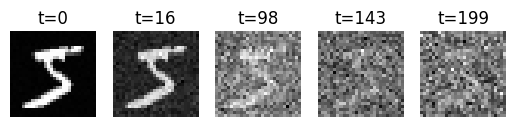

In [5]:
mnist=torchvision.datasets.MNIST(root='.',train=True,download=True,
                                transform=torchvision.transforms.Compose([transforms.ToTensor(),
                                                                         transforms.Normalize((0.5,),(0.5,))]))
x0,_=mnist[0]
ts=[0,16,98,143,199]
fig, axes = plt.subplots(1, len(ts))
for i, t in enumerate(ts):
    xt,_ = diffusey(x0, t)
    axes[i].imshow(xt.squeeze().detach().cpu().numpy(), cmap="gray")
    axes[i].set_title(f"t={t}")
    axes[i].axis("off")
plt.show()

In [6]:
def tembed(t,dim=128):
    half=dim//2
    emb=torch.exp(torch.arange(half,device=dev)*-torch.log(torch.tensor(10000.0))/(half-1))
    emb=t[:,None]*emb[None,:]
    return torch.cat([torch.sin(emb),torch.cos(emb)],dim=1)

In [7]:
class VanDiffu(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1=nn.Conv2d(1,64,3,padding=1)
        self.c2=nn.Conv2d(64,64,3,padding=1)
        self.c3=nn.Conv2d(64,64,3,padding=1)
        self.c4=nn.Conv2d(64,1,3,padding=1)
        self.tproj=nn.Linear(128,64)
    def forward(self,x,t):
        tem=tembed(t,128)
        tem=self.tproj(tem).view(-1,64,1,1)
        out=funcy.relu(self.c1(x))
        out=out+tem
        res=out
        out=funcy.relu(self.c3(funcy.relu(self.c2(out))))
        out=out+res
        return self.c4(out)

In [8]:
load=DataLoader(mnist,batch_size=128,shuffle=True)

In [9]:
model=VanDiffu().to(dev)
optim=torch.optim.Adam(model.parameters(),lr=1e-3)

In [10]:
eps=150

In [11]:
for ep in range(eps):
    for imgs,_ in load:
        imgs=imgs.to(dev)
        t=torch.randint(0,T,(imgs.size(0),),device=dev)
        xt,noi=diffusey(imgs,t)
        pred=model(xt,t)
        loss=funcy.mse_loss(pred,noi)
        optim.zero_grad()
        loss.backward()
        optim.step()
    print(f'{ep} Loss={loss.item():.4f}')

0 Loss=0.0828
1 Loss=0.0764
2 Loss=0.0610
3 Loss=0.0644
4 Loss=0.0783
5 Loss=0.0648
6 Loss=0.0599
7 Loss=0.0645
8 Loss=0.0602
9 Loss=0.0649
10 Loss=0.0650
11 Loss=0.0588
12 Loss=0.0642
13 Loss=0.0652
14 Loss=0.0668
15 Loss=0.0556
16 Loss=0.0591
17 Loss=0.0591
18 Loss=0.0655
19 Loss=0.0589
20 Loss=0.0586
21 Loss=0.0624
22 Loss=0.0606
23 Loss=0.0556
24 Loss=0.0604
25 Loss=0.0597
26 Loss=0.0545
27 Loss=0.0577
28 Loss=0.0549
29 Loss=0.0586
30 Loss=0.0519
31 Loss=0.0558
32 Loss=0.0526
33 Loss=0.0554
34 Loss=0.0573
35 Loss=0.0565
36 Loss=0.0568
37 Loss=0.0533
38 Loss=0.0569
39 Loss=0.0577
40 Loss=0.0490
41 Loss=0.0522
42 Loss=0.0578
43 Loss=0.0579
44 Loss=0.0635
45 Loss=0.0585
46 Loss=0.0578
47 Loss=0.0547
48 Loss=0.0576
49 Loss=0.0524
50 Loss=0.0608
51 Loss=0.0517
52 Loss=0.0604
53 Loss=0.0575
54 Loss=0.0582
55 Loss=0.0554
56 Loss=0.0541
57 Loss=0.0620
58 Loss=0.0574
59 Loss=0.0531
60 Loss=0.0467
61 Loss=0.0539
62 Loss=0.0530
63 Loss=0.0539
64 Loss=0.0544
65 Loss=0.0574
66 Loss=0.0662
67 Lo

In [12]:
@torch.no_grad()
def sampling(model,n=1):
    model.eval()
    x=torch.randn(n,1,28,28).to(dev)
    for t in reversed(range(T)):
        tb=torch.full((n,),t,device=dev)
        eps=model(x,tb)
        a=alp[t]
        a_bar=balp[t]
        b=beta[t]
        x=(1/torch.sqrt(a))*(x-(1-a)/torch.sqrt(1-a_bar)*eps)
        if t>0:
            x+=torch.sqrt(b)*torch.randn_like(x)
    print(t, torch.sqrt(1 - balp[t]).item())
    return x

0 0.010000829584896564


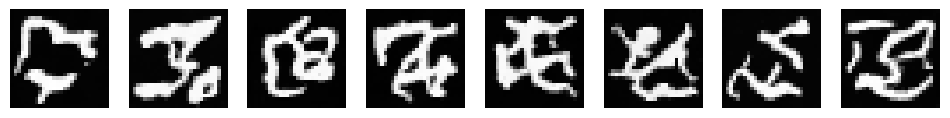

In [13]:
sam=sampling(model,n=8).cpu()
fig, axes = plt.subplots(1, 8, figsize=(12,2))
for i in range(8):
    axes[i].imshow(sam[i].squeeze(), cmap="gray")
    axes[i].axis("off")
plt.show()